How are in-demand skills trending for Data Analysts?
Methology
Aggregate skill counts monthly
Re-analyze based on percentage of total jobs
Plot the monthly skill demand
Original Exploration


In [1]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
df_DA_Srb = df[(df["job_title_short"] == "Data Analyst") & (df["job_country"] == "Serbia")].copy()
df_DA_Srb["job_posted_month_no"] = df_DA_Srb["job_posted_date"].dt.month
df_DA_Srb.head(5)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
3202,Data Analyst,Master Data Analyst,"Novi Sad, Serbia",via LinkedIn,Full-time,False,Serbia,2023-11-05 13:57:35,False,False,Serbia,None,NaN,NaN,Hisense Europe,"[excel, spreadsheet]","{'analyst_tools': ['excel', 'spreadsheet']}",11
9313,Data Analyst,Senior Workforce Analyst - HR Analytics,"Belgrade, Serbia",via LinkedIn,Full-time,False,Serbia,2023-12-19 13:35:23,True,False,Serbia,None,NaN,NaN,FIS,[go],{'programming': ['go']},12
13513,Data Analyst,Data Analyst/Business growth analyst,"Belgrade, Serbia",via LinkedIn,Full-time,False,Serbia,2023-02-27 13:31:44,True,False,Serbia,None,NaN,NaN,Data-Driven Lab,"[python, sql, scala, postgresql, databricks, g...","{'async': ['jira', 'confluence'], 'cloud': ['d...",2
17363,Data Analyst,Data Analyst - Intern,"Belgrade, Serbia",via SmartRecruiters Job Search,Full-time,False,Serbia,2023-08-25 13:32:21,False,False,Serbia,None,NaN,NaN,Bosch Group,"[sql, python]","{'programming': ['sql', 'python']}",8
20751,Data Analyst,KICKSTART - Reporting Analyst Intern,"Belgrade, Serbia",via LinkedIn Serbia,Temp work and Internship,False,Serbia,2023-10-13 14:05:30,False,False,Serbia,None,NaN,NaN,Yettel.Srbija,"[sql, express, excel, powerpoint, spss]","{'analyst_tools': ['excel', 'powerpoint', 'sps...",10


In [8]:
df_DA_Srb_explode = df_DA_Srb.explode("job_skills")
df_DA_Srb_explode.head(5)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
3202,Data Analyst,Master Data Analyst,"Novi Sad, Serbia",via LinkedIn,Full-time,False,Serbia,2023-11-05 13:57:35,False,False,Serbia,None,NaN,NaN,Hisense Europe,excel,"{'analyst_tools': ['excel', 'spreadsheet']}",11
3202,Data Analyst,Master Data Analyst,"Novi Sad, Serbia",via LinkedIn,Full-time,False,Serbia,2023-11-05 13:57:35,False,False,Serbia,None,NaN,NaN,Hisense Europe,spreadsheet,"{'analyst_tools': ['excel', 'spreadsheet']}",11
9313,Data Analyst,Senior Workforce Analyst - HR Analytics,"Belgrade, Serbia",via LinkedIn,Full-time,False,Serbia,2023-12-19 13:35:23,True,False,Serbia,None,NaN,NaN,FIS,go,{'programming': ['go']},12
13513,Data Analyst,Data Analyst/Business growth analyst,"Belgrade, Serbia",via LinkedIn,Full-time,False,Serbia,2023-02-27 13:31:44,True,False,Serbia,None,NaN,NaN,Data-Driven Lab,python,"{'async': ['jira', 'confluence'], 'cloud': ['d...",2
13513,Data Analyst,Data Analyst/Business growth analyst,"Belgrade, Serbia",via LinkedIn,Full-time,False,Serbia,2023-02-27 13:31:44,True,False,Serbia,None,NaN,NaN,Data-Driven Lab,sql,"{'async': ['jira', 'confluence'], 'cloud': ['d...",2


In [27]:
df_DA_Srb_pivot = df_DA_Srb_explode.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)
df_DA_Srb_pivot.loc["total"] = df_DA_Srb_pivot.sum()
df_DA_Srb_pivot = df_DA_Srb_pivot[df_DA_Srb_pivot.loc["total"].sort_values(ascending=False).index]
df_DA_Srb_pivot = df_DA_Srb_pivot.drop("total")
df_DA_Srb_pivot

job_skills,sql,python,excel,tableau,power bi,r,sap,sas,c#,spss,...,docker,gitlab,golang,google chat,kubernetes,matplotlib,microstrategy,planner,plotly,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,3,3,3,4,3,1,4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,6,8,4,1,4,2,2,0,1,...,0,0,0,0,0,0,1,0,0,0
3,11,8,7,8,6,9,2,8,2,3,...,0,0,0,0,0,0,0,0,0,0
4,7,10,6,8,4,2,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,8,4,5,4,3,2,3,2,1,2,...,0,0,0,0,0,0,0,0,0,0
6,8,6,8,3,3,3,2,2,0,3,...,0,0,0,0,0,1,0,1,0,0
7,8,8,3,4,2,1,1,2,2,1,...,0,0,0,0,0,0,0,0,0,0
8,15,12,3,5,4,1,1,0,4,0,...,0,0,0,0,0,0,0,0,0,0
9,10,5,3,5,8,0,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df_DA_total = df_DA_Srb.groupby("job_posted_month_no").size()
df_DA_total

job_posted_month_no
1     11
2     19
3     24
4     17
5     17
6     19
7     13
8     18
9     10
10    14
11    20
12    13
dtype: int64

In [34]:
df_DA_Srb_perc = df_DA_Srb_pivot.div(df_DA_total/100, axis=0)
df_DA_Srb_perc

job_skills,sql,python,excel,tableau,power bi,r,sap,sas,c#,spss,...,docker,gitlab,golang,google chat,kubernetes,matplotlib,microstrategy,planner,plotly,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,27.272727,27.272727,27.272727,36.363636,27.272727,9.090909,36.363636,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,47.368421,31.578947,42.105263,21.052632,5.263158,21.052632,10.526316,10.526316,0.000000,5.263158,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.263158,0.000000,0.000000,0.000000
3,45.833333,33.333333,29.166667,33.333333,25.000000,37.500000,8.333333,33.333333,8.333333,12.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,41.176471,58.823529,35.294118,47.058824,23.529412,11.764706,5.882353,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,47.058824,23.529412,29.411765,23.529412,17.647059,11.764706,17.647059,11.764706,5.882353,11.764706,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,42.105263,31.578947,42.105263,15.789474,15.789474,15.789474,10.526316,10.526316,0.000000,15.789474,...,0.000000,0.000000,0.000000,0.000000,0.000000,5.263158,0.000000,5.263158,0.000000,0.000000
7,61.538462,61.538462,23.076923,30.769231,15.384615,7.692308,7.692308,15.384615,15.384615,7.692308,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,83.333333,66.666667,16.666667,27.777778,22.222222,5.555556,5.555556,0.000000,22.222222,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,100.000000,50.000000,30.000000,50.000000,80.000000,0.000000,10.000000,0.000000,20.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


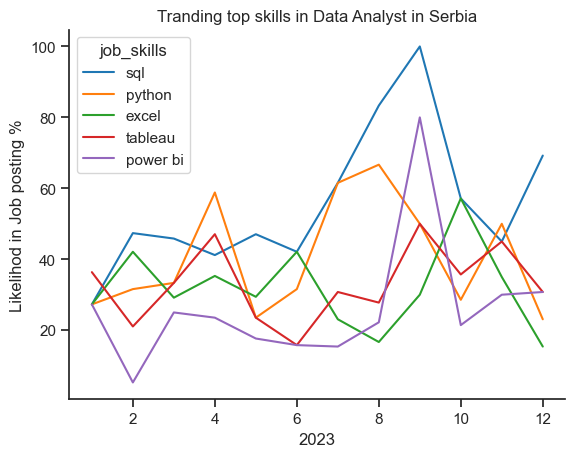

In [52]:
df_plot = df_DA_Srb_perc.iloc[:,:5]

sns.lineplot(data=df_plot, dashes=False, palette="tab10")
sns.set_theme(style="ticks")

plt.title("Tranding top skills in Data Analyst in Serbia")
plt.ylabel("Likelihod in Job posting %")
plt.xlabel(2023)
sns.despine()

#plt.legend().remove()

#plt.xlim(1, 13.5)

#offsets = [5, 3, 1, -2, -5]
#for i in range(5):
 #   plt.text(12.5, df_plot.iloc[-1, i] + offsets[i], df_plot.columns[i])